<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

# **Loading the dataset**

In [3]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
visa= pd.read_csv('/content/drive/Othercomputers/My PC/PGP Course Work/ADV ML M3/EasyVisa.csv')
data=visa.copy()

# **Overview of the Dataset**

* Observations

* Sanity checks

In [5]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
data.shape

(25480, 12)

The dataset have 25480 rows and 12 columns in total.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


There is total of 3 numerical and 9 categorical columns.

In [8]:
data.isnull().sum() #We can use .isnull().sum() to find any missing calues in the columns

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are no null values in the dataset

In [9]:
data.duplicated().sum()

np.int64(0)

There are no duplicated values in the dataset.

In [10]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Key Observations

Here's what we've gathered from a preliminary look at our dataset:

*   **Applicant Origin**: Our data shows visa applicants come from six different continents, with the vast majority (over 60%) hailing from Asia.
*   **Education Levels**: A significant portion of the employees applying for visas possess a Bachelor's degree, indicating a well-educated applicant pool.
*   **Work Experience**: Over half of the applicants have previous job experience, suggesting a preference for experienced professionals.
*   **Employer Size**: The number of employees in sponsoring companies varies widely, from small businesses to large corporations with over 600,000 employees. The average company size is around 5,668 employees. (Note: I've already corrected some erroneous negative employee counts found in the raw data).
*   **Prevailing Wage**: The average salary for a specific role in an area (prevailing wage) spans a broad range, from as little as $2 to over $319,000, with an average of about $74,455. This wide range implies that wages might be reported on different bases, such as hourly or annually.
*   **Job Type**: Most visa applications are for full-time positions, indicating a strong demand for permanent roles.
*   **Outcome Prediction**: Our main objective is to predict the 'case status' – whether a visa application will be certified or denied – which serves as our target variable for the model.

In [11]:
# Let's see how many values are negative in no_of_employess
data.loc[data["no_of_employees"] < 0].shape

(33, 12)

In [12]:
# Lets fix the negative values in the column to be absolute value
data["no_of_employees"] = abs(data["no_of_employees"])

In [13]:
# Making a list of all categorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts()) ##  Complete the code to print the count of each unique value in each column
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [14]:
data["case_id"].nunique()

25480

In [15]:
# dropping the case_id column since it is a unique coloum and dropping it won't be affecting the data
data.drop(["case_id"], axis=1, inplace=True)

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [16]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

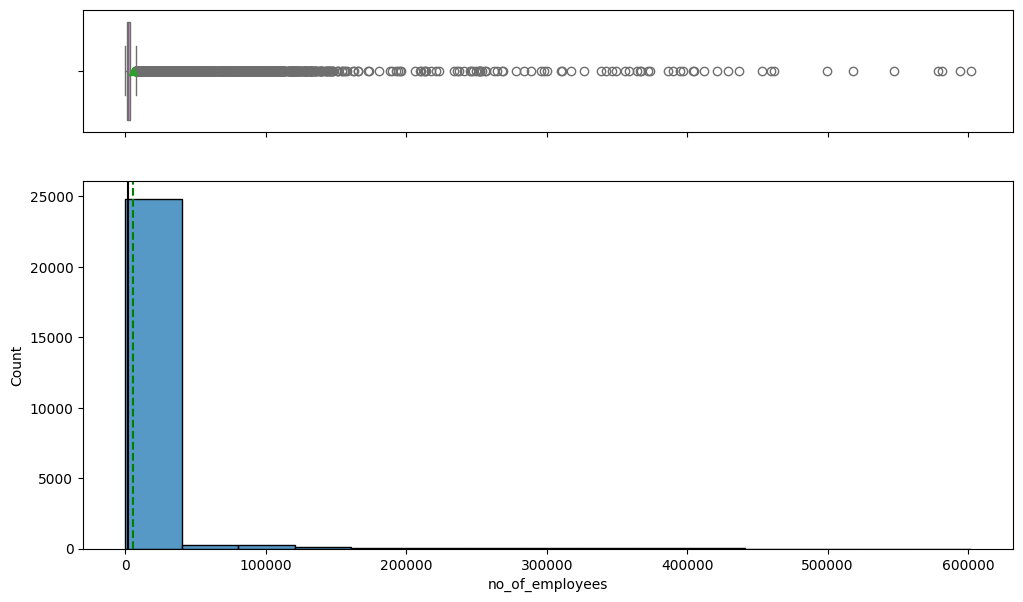

In [17]:
histogram_boxplot(data,"no_of_employees",bins=15)

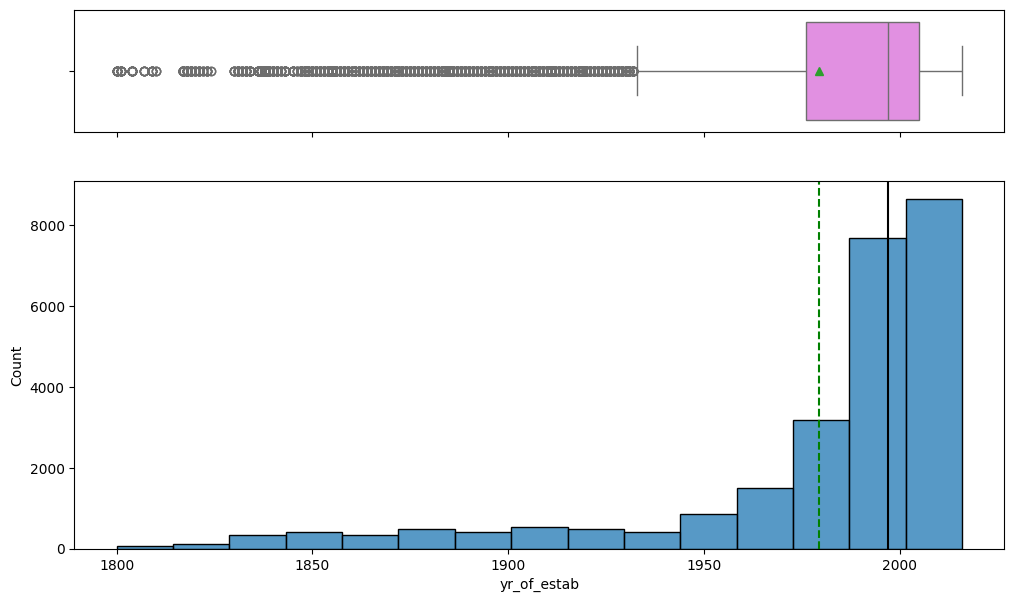

In [18]:
histogram_boxplot(data,"yr_of_estab",bins=15)

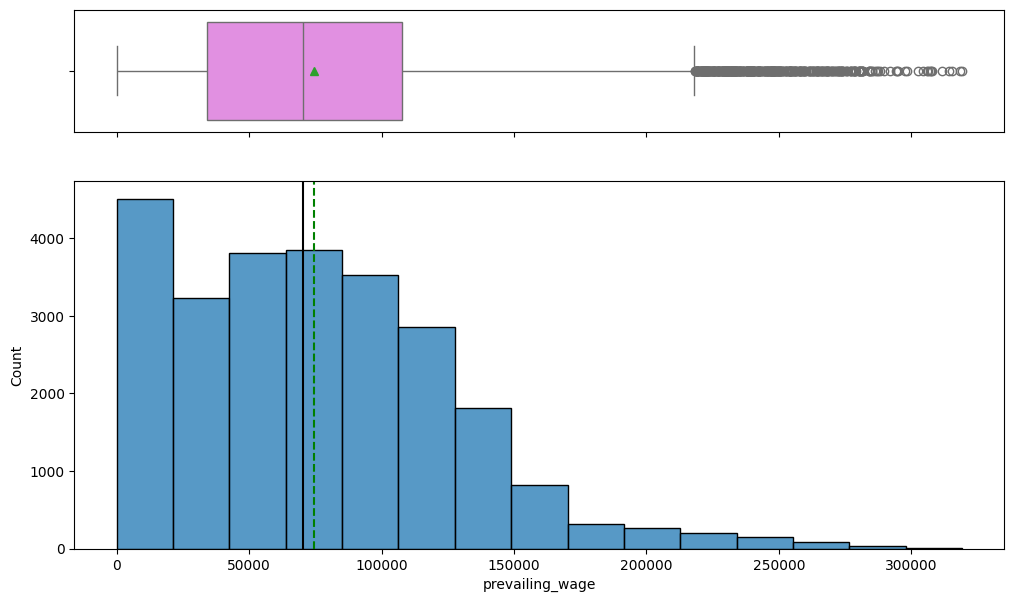

In [19]:
histogram_boxplot(data,"prevailing_wage",bins=15)

### Observations from Numerical Features

*   **`no_of_employees`**: The distribution is highly skewed to the right, with a majority of companies having fewer employees and a long tail extending to companies with a very large number of employees. This suggests potential outliers on the higher end.
*   **`yr_of_estab`**: The distribution of the year of establishment is spread across a wide range, indicating companies established from the 1800s to the early 2000s. There might be some older companies with a high number of employees.
*   **`prevailing_wage`**: The prevailing wage also shows a right-skewed distribution, with a concentration of lower wages and a presence of higher wage outliers.

In [20]:
# function to create labeled barplots

def labeled_barplot(data, feature_list, perc=False, n=None):
    """
    Barplot with percentage at the top for multiple features in subplots

    data: dataframe
    feature_list: list of dataframe columns (strings) or a single dataframe column (string)
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels for each feature)
    """
    if isinstance(feature_list, str):
        features_to_plot = [feature_list]
    else:
        features_to_plot = feature_list

    ncols = 3
    nrows = -(-len(features_to_plot) // ncols)  # Calculate nrows based on number of features

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8 * ncols, 5 * nrows))
    axes = np.array(axes).flatten() # Flatten axes for easy iteration

    for i, feature_name in enumerate(features_to_plot):
        ax = axes[i] # Get the current subplot axis

        # Calculate total for percentage based on the current feature column
        total_for_perc = len(data[feature_name])

        sns.countplot(
            data=data,
            x=feature_name,
            palette="Blues",
            order=data[feature_name].value_counts().index[:n].sort_values(),
            ax=ax # Plot on the specific subplot axis
        )

        ax.tick_params(axis="x", rotation=90, labelsize=10) # Adjust x-tick parameters for subplot
        ax.set_title(feature_name, fontsize=12, fontweight="bold") # Set title for each subplot
        ax.set_xlabel("") # Clear x-label to avoid clutter

        for p in ax.patches:
            if perc:
                label = "{:.1f}%".format(100 * p.get_height() / total_for_perc)
            else:
                label = p.get_height()

            x = p.get_x() + p.get_width() / 2
            y = p.get_height()

            ax.annotate(
                label,
                (x, y),
                ha="center",
                va="center",
                size=9, # Smaller font size for annotations in subplots
                xytext=(0, 5),
                textcoords="offset points",
            )

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout() # Adjust layout to prevent overlapping
    plt.show()

In [ ]:
labeled_barplot(data, data.select_dtypes(include="object").columns.tolist(), perc=True)


### Observations from Categorical Features

*   **`case_status`**: The dataset shows a significant class imbalance, with a majority of visa applications being Certified (66.8%) compared to Denied (33.2%). This imbalance will need to be addressed during model building.
*   **`continent`**: A large proportion of applicants (over 60%) come from Asia, followed by Europe and North America. This indicates a strong presence of Asian applicants in the visa application process.
*   **`education_of_employee`**: The majority of employees have either a Bachelor's (40.2%) or Master's (37.8%) degree, suggesting that higher education levels are common among applicants. High School and Doctorate degrees are less frequent.
*   **`has_job_experience`**: More employees (58.1%) possess job experience than those without (41.9%), which could be an important factor in visa approval.
*   **`requires_job_training`**: The vast majority of applicants (88.4%) do not require job training, implying that most applicants are expected to be job-ready.
*   **`region_of_employment`**: The Northeast, South, and West regions are the primary regions of employment, with the Northeast having the highest percentage of positions.
*   **`unit_of_wage`**: Most prevailing wages are reported on a Yearly (90.1%) basis, followed by Hourly. Weekly and Monthly wage units are comparatively rare.
*   **`full_time_position`**: The overwhelming majority of positions (89.4%) are full-time, indicating that most visa applications are for full-time employment.

BIVARIANT

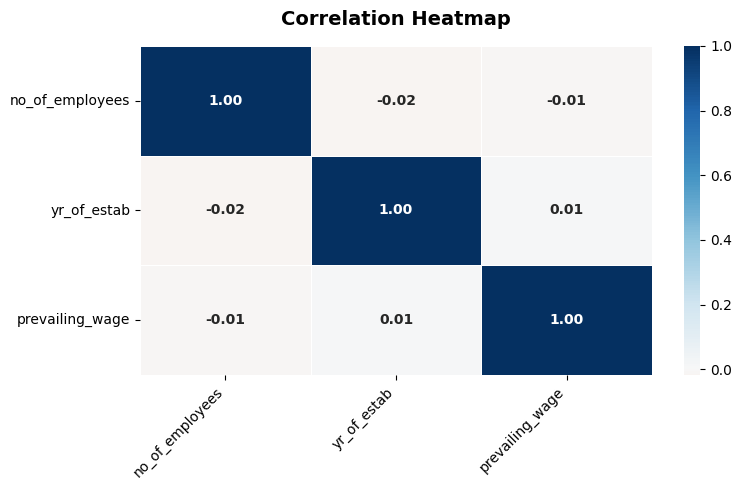

In [21]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    data.select_dtypes(include=np.number).corr(),
    annot=True,                  # show correlation values
    fmt=".2f",                   # 2 decimal places
    cmap="RdBu",             # blue to red colormap
    center=0,                    # center colormap at 0
    linewidths=0.5,              # grid lines between cells
    linecolor="white",           # grid line color
    annot_kws={"size": 10, "fontweight": "bold"}  # annotation style
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

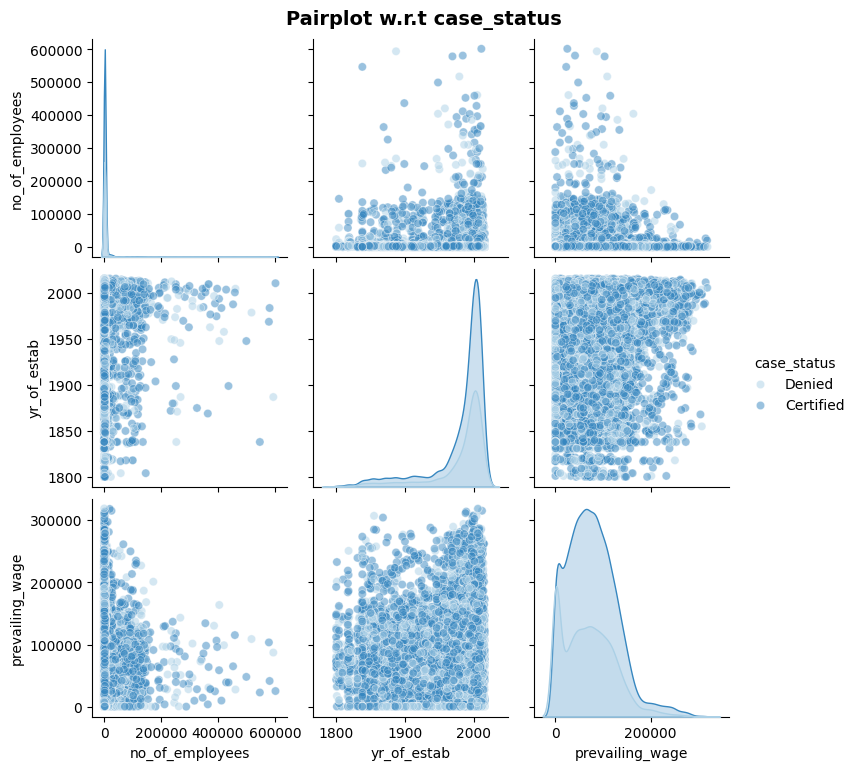

In [22]:

cols = data.select_dtypes(include=np.number).columns.tolist()

sns.pairplot(data=data[cols + ["case_status"]],
             hue="case_status",
             palette="Blues",
             diag_kind="kde",
             plot_kws={"alpha": 0.5})

plt.suptitle("Pairplot w.r.t case_status", fontsize=14, fontweight="bold", y=1.02)
plt.show()

In [23]:
def stack_barplot(data, predictors, target):
    if isinstance(predictors, str):
        predictors = [predictors]

    n = len(predictors)
    ncols = 3
    nrows = -(-n // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    for i, predictor in enumerate(predictors):
        ax = axes[i]
        sorter = data[target].value_counts().index[-1]

        tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(by=sorter, ascending=False)
        tab.plot(kind="bar", stacked=True, ax=ax, legend=(i == 0))

        for bar_container in ax.containers:
            for bar in bar_container:
                height = bar.get_height()
                if height > 0.03:  # skip tiny segments
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + height / 2,
                        f"{height*100:.1f}%",
                        ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold"
                    )

        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))

        ax.set_title(predictor, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

        if i == 0:
            ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Stacked Bar Charts by {target}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

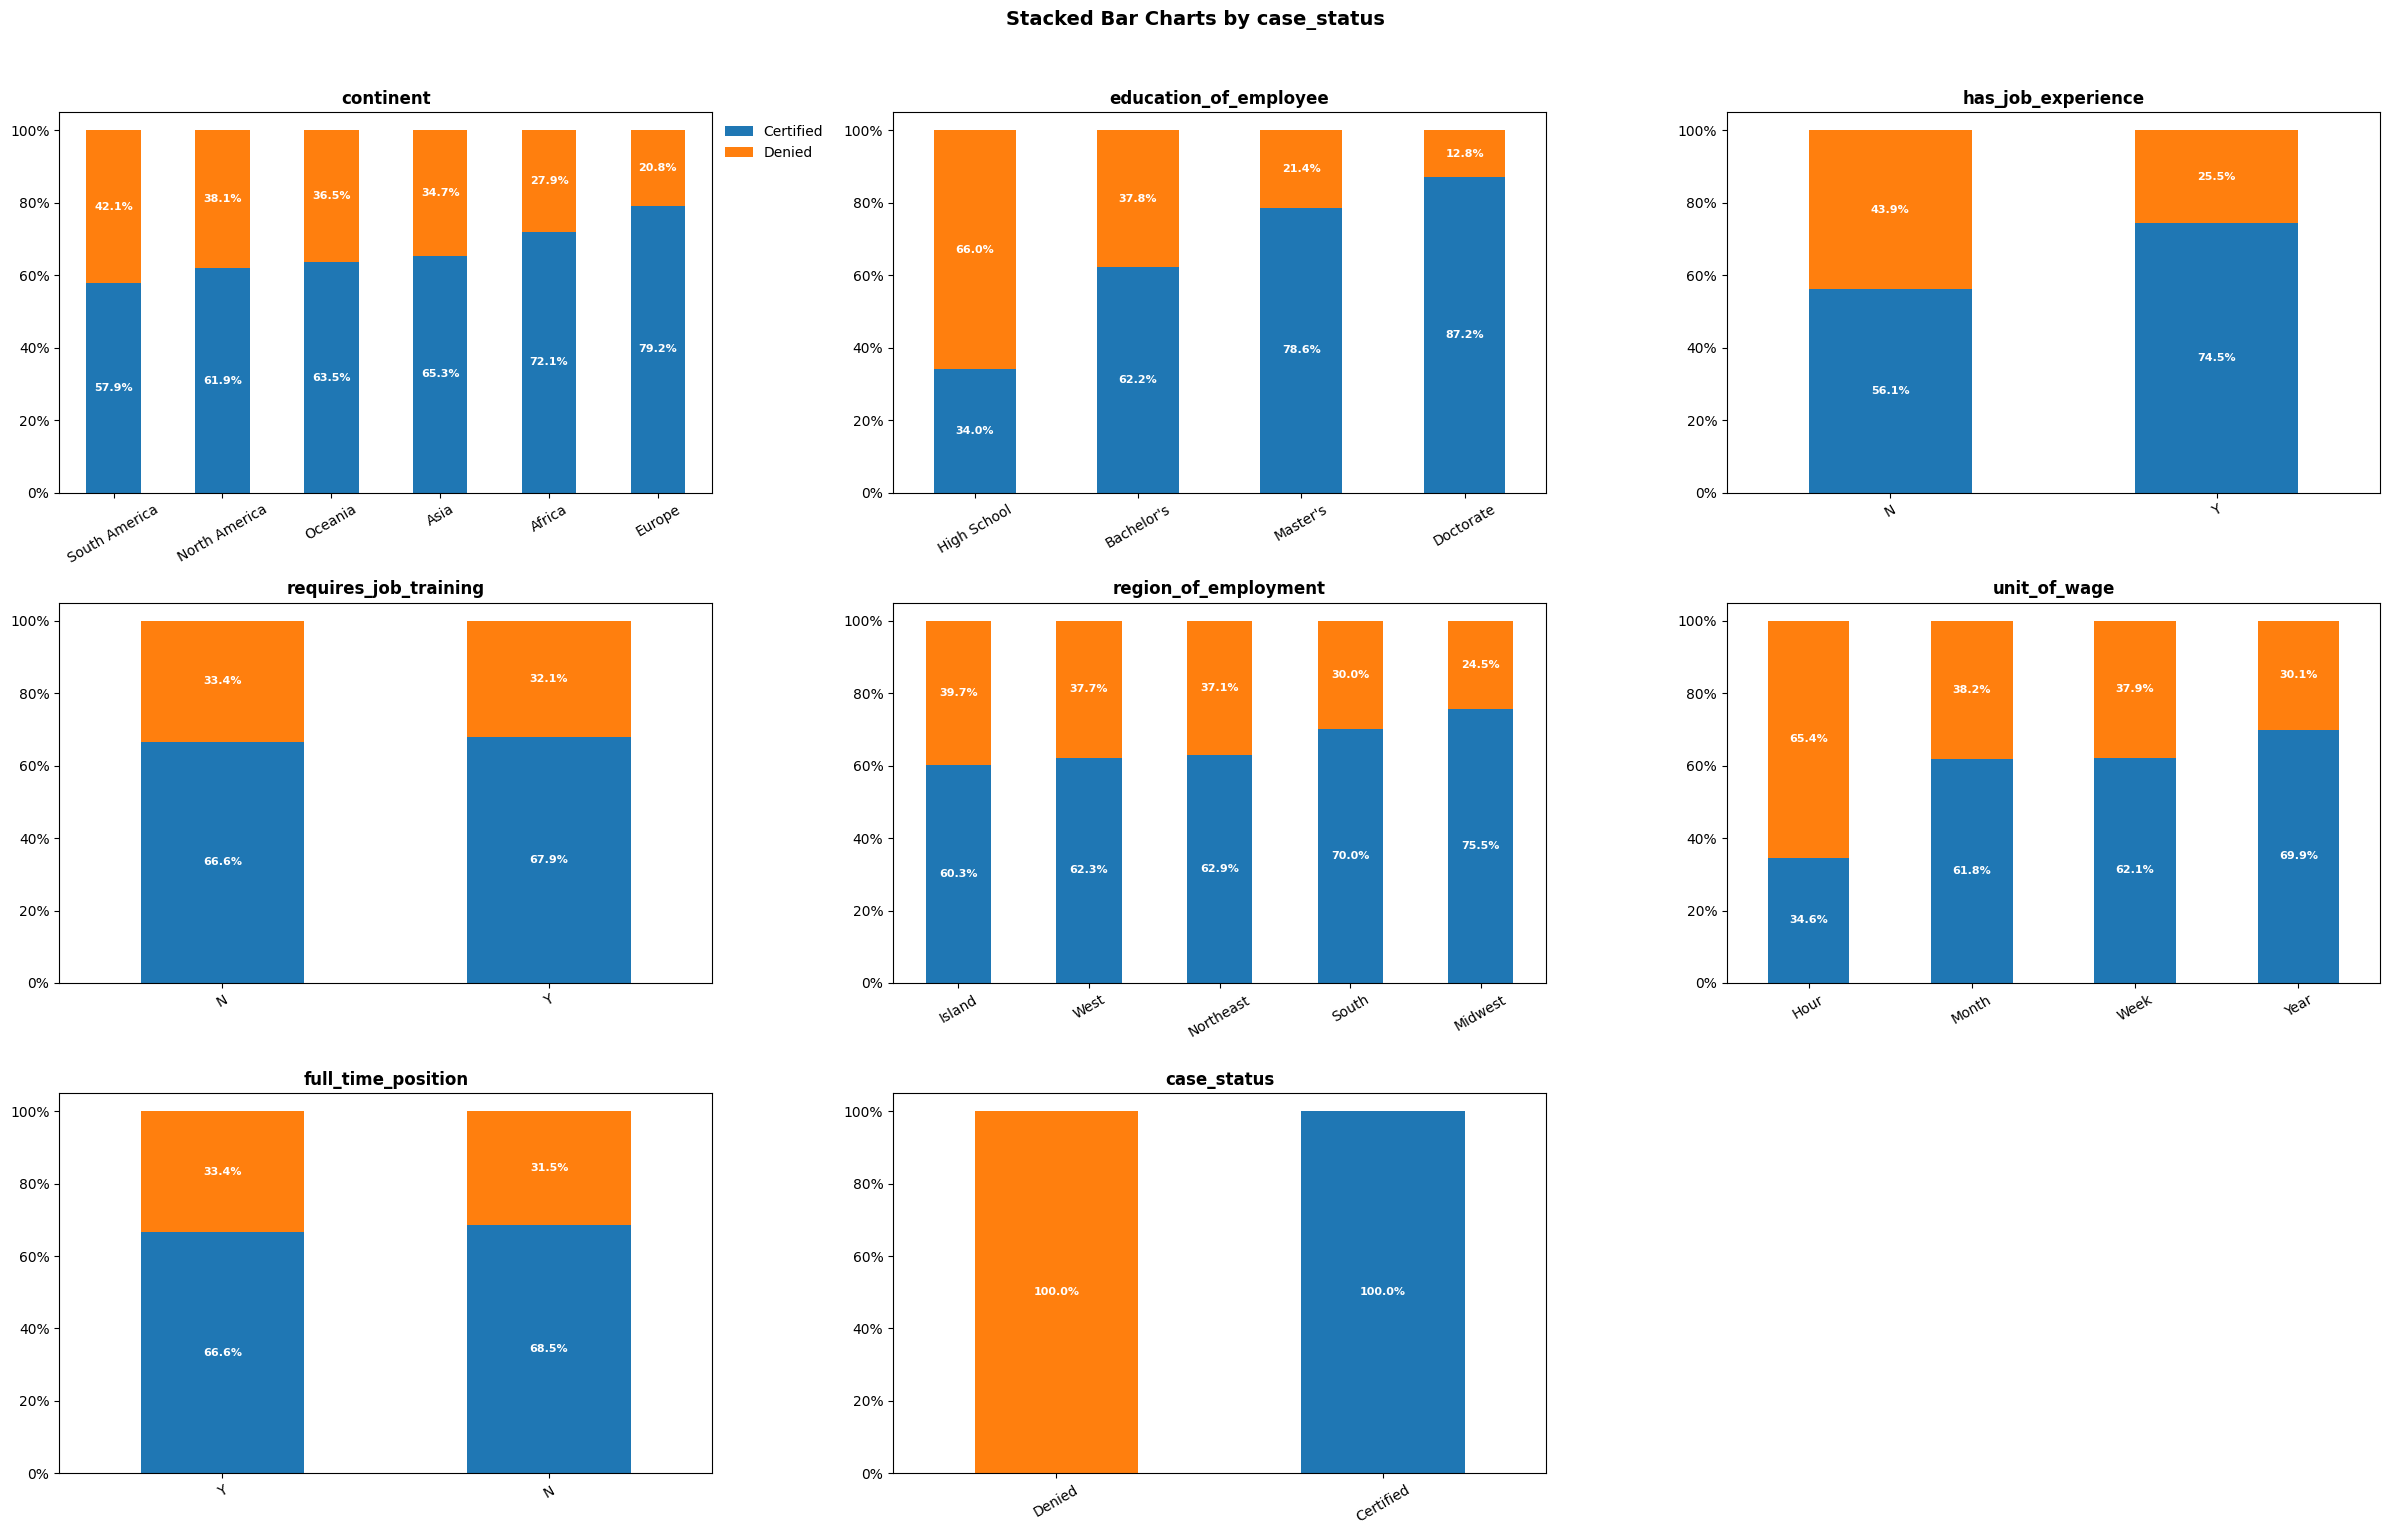

In [24]:
stack_barplot(data, data.select_dtypes(include="object").columns.tolist(), "case_status")

In [25]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(8,5))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="#4472C4",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="#ED7D31",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0],palette=["#4472C4", "#ED7D31"])

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
       palette=["#4472C4", "#ED7D31"]
    )

    plt.tight_layout()
    plt.show()

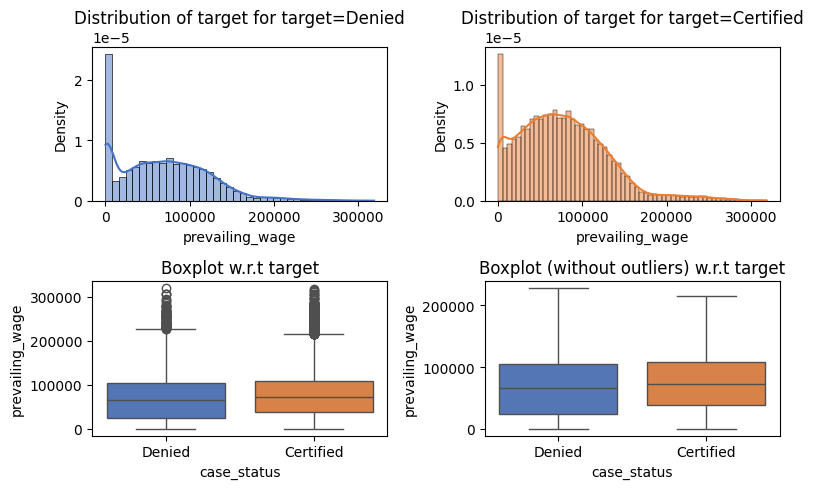

In [26]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

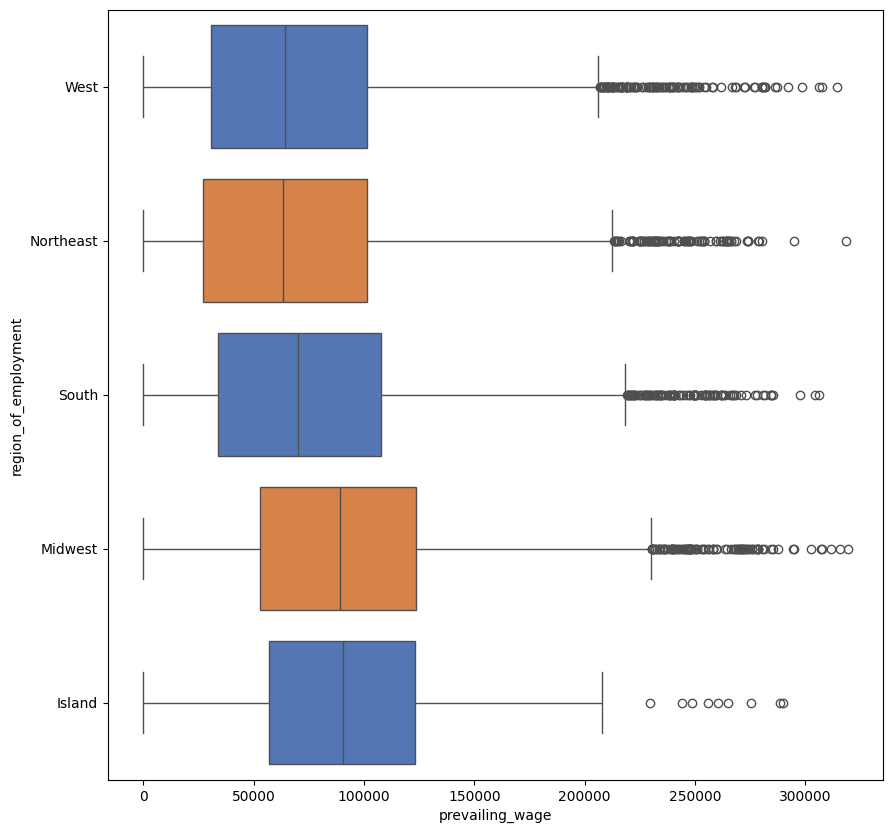

In [27]:
plt.figure(figsize=(10, 10))
sns.boxplot(x="prevailing_wage", y="region_of_employment", data=data,palette=["#4472C4", "#ED7D31"])
plt.show()


### Observations from Bivariate Analysis

*   **Correlation Heatmap**: Numerical features (`no_of_employees`, `yr_of_estab`, `prevailing_wage`) show very weak linear correlations among themselves, suggesting that they are largely independent of each other.
*   **Pairplot**: The pairplot of numerical features against `case_status` indicates that there is no clear linear separation between Certified and Denied cases based on these numerical features alone. The distributions largely overlap.
*   **Stacked Bar Plots (Categorical vs. `case_status`)**:
    *   **Continent**: From the stacked bar plots, it appears South America has the highest denial rate (around 42%), followed by Asia (around 34%). Europe, North America, and South America show higher certification rates overall compared to Africa and Oceania.
    *   **Education of Employee**: Applicants with Bachelor's and Master's degrees show similar approval rates. Doctorate holders have a slightly higher approval rate, while High School educated applicants have a considerably lower approval rate.
    *   **Has Job Experience**: Employees with job experience (`Y`) have a significantly higher visa approval rate compared to those without job experience (`N`).
    *   **Requires Job Training**: A very high percentage of applicants who do not require job training (`N`) are certified, suggesting that being job-ready is a strong positive factor for visa approval.
    *   **Region of Employment**: The regions of Northeast, South, and West have similar certification rates, while Island and Midwest regions show some variation, with Island having a lower certification rate.
    *   **Unit of Wage**: The unit of wage (Year, Hour, Week, Month) does not seem to have a drastic impact on the case status, though 'Hourly' wages might see slightly more denials.
    *   **Full-time Position**: Full-time positions (`Y`) have a higher certification rate than part-time positions (`N`).
*   **Distribution Plot (`prevailing_wage` vs. `case_status`)**: The distribution of prevailing wage for certified and denied cases shows considerable overlap. However, there might be a slight tendency for lower prevailing wages to be associated with denied cases, while higher wages are more spread out for certified cases.
*   **Boxplot (`prevailing_wage` vs. `region_of_employment`)**: The prevailing wage varies across different regions of employment, with some regions potentially having higher average wages than others. This plot helps understand regional wage differences, which could indirectly influence visa outcomes depending on the `case_status` distribution within each region.

# **Data Pre-processing**

Before building the models, it's essential to preprocess the data. This involves handling categorical variables, scaling numerical features, and potentially addressing class imbalance.

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

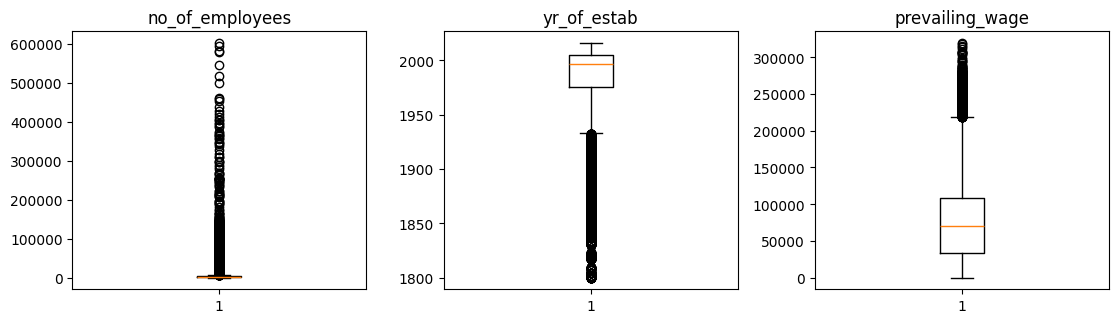

In [28]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [29]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

X = data.drop(["case_status"], axis=1)
y = data["case_status"]


X = pd.get_dummies(X, drop_first=True)
# X = X.astype(float)

# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [30]:
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 21)
Shape of the Validation set:  (5096, 21)
Shape of test set :  (5096, 21)
Percentage of classes in training set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


# **Model Building**

# **Model Building**

## Model evaluation criterion

**Model can make wrong predictions as**:

1. Model predicts that the visa application will get certified but in reality, the visa application should get denied.
2. Model predicts that the visa application will not get certified but in reality, the visa application should get certified.

**Which case is more important?**
* Both the cases are important as:

* If a visa is certified when it had to be denied a wrong employee will get the job position while US citizens will miss the opportunity to work on that position.

* If a visa is denied when it had to be certified the U.S. will lose a suitable human resource that can contribute to the economy.


**How to reduce the losses?**

* `F1 Score` can be used a the metric for evaluation of the model, greater the F1  score higher are the chances of minimizing False Negatives and False Positives.
* We will use balanced class weights so that model focuses equally on both classes.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearn function will be used to plot the confusion matrix.

In [31]:
#defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [32]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Model Building - Original Data

In [33]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.989150179193873
Random Forest: 1.0
GBM: 0.8291218182658106
Adaboost: 0.8204269947530306
dtree: 1.0

Validation Performance:

Bagging: 0.7736516357206012
Random Forest: 0.8049978941457251
GBM: 0.826637008202419
Adaboost: 0.8180081855388813
dtree: 0.7486033519553073


In [34]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9867, Validation Score: 0.7712, Difference: 0.2155
Random Forest: Training Score: 1.0000, Validation Score: 0.8422, Difference: 0.1578
GBM: Training Score: 0.8789, Validation Score: 0.8734, Difference: 0.0056
Adaboost: Training Score: 0.8882, Validation Score: 0.8807, Difference: 0.0075
dtree: Training Score: 1.0000, Validation Score: 0.7479, Difference: 0.2521


### Observations on Model Performance and Overfitting

Based on the training and validation recall scores, we can make the following observations:

*   **Bagging**: Exhibits significant overfitting (Gap: 0.2155), indicating high variance and memorization of training data.
*   **Random Forest**: Also shows signs of overfitting (Gap: 0.1578). A perfect training score suggests it might be memorizing the training data too well, leading to poorer generalization.
*   **GBM (Gradient Boosting Machine)**: Demonstrates a good fit with a very small gap (0.0056) between training and validation scores. This model generalizes excellently to unseen data.
*   **Adaboost**: Emerges as the best choice, with a tiny gap (0.0075) and a strong validation score, suggesting it generalizes very well and balances bias-variance effectively.
*   **Decision Tree**: Shows the worst overfitting (Gap: 0.2521), indicating little to no regularization and pure memorization of the training data.

In [35]:
print(data['case_status'].value_counts())
print(data['case_status'].value_counts(normalize=True).mul(100).round(2))

case_status
1    17018
0     8462
Name: count, dtype: int64
case_status
1    66.79
0    33.21
Name: proportion, dtype: float64


###Observation
The 2:1 ratio (67% Certified, 33% Denied) in `case_status` is not a severe class imbalance, as the model sees enough 'Denied' cases. Therefore, oversampling or undersampling techniques are not strictly necessary. Furthermore, using F1-score as the evaluation metric inherently addresses potential impacts of class imbalance by balancing precision and recall.

# **Model Performance Improvement**

## Hyperparameter Tuning - Random Forest

In [36]:
%%time

rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True)

parameters = {
    "n_estimators": [50, 110, 25],
    "min_samples_leaf": np.arange(1, 4),        # [1, 2, 3]
    "max_features": ["sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1)     # [0.4, 0.5, 0.6]
}

acc_scorer = metrics.make_scorer(metrics.f1_score)

grid_obj = GridSearchCV(rf_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

rf_tuned = grid_obj.best_estimator_
rf_tuned.fit(X_train, y_train)


CPU times: user 6.08 s, sys: 161 ms, total: 6.24 s
Wall time: 2min 21s


RandomForestClassifier(max_samples=np.float64(0.5),
                       min_samples_leaf=np.int64(3), n_estimators=110,
                       oob_score=True, random_state=1)

### Checking model performance on training set

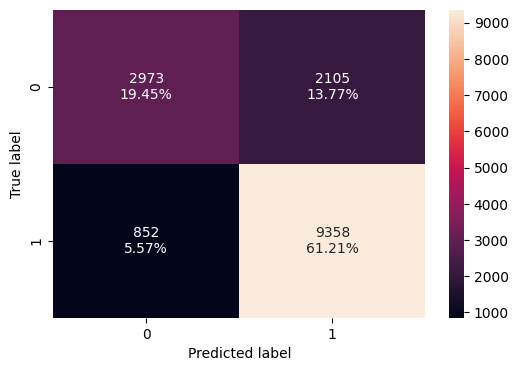

In [37]:
confusion_matrix_sklearn(rf_tuned, X_train, y_train)

In [38]:
rf_tuned_model_train_perf = model_performance_classification_sklearn(
    rf_tuned, X_train, y_train
)
rf_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.80658,0.916552,0.816366,0.863563


### Checking model performance on validation set

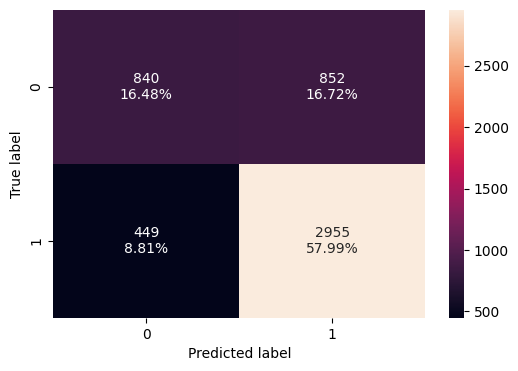

In [39]:
confusion_matrix_sklearn(rf_tuned, X_val, y_val)

In [40]:
rf_tuned_model_val_perf = model_performance_classification_sklearn(
    rf_tuned, X_val, y_val
)
rf_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.744702,0.868096,0.776202,0.819581


### Observations:

After hyperparameter tuning, the Random Forest model shows a reduced train-validation F1 gap, improving from a large gap (untuned F1 train: 1.0, val: 0.8050) to a smaller gap (tuned F1 train: 0.8636, val: 0.8196), indicating better generalization. The validation F1 score slightly increased from 0.8050 to 0.8196. The model still results in approximately 852 Denied cases being misclassified as Certified (False Positives) and 449 Certified cases being misclassified as Denied (False Negatives) on the validation set, suggesting room for improvement in handling both classes.

## Hyperparameter Tuning - AdaBoost Classifier

In [41]:
%%time
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Let's try different max_depth for base_estimator
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": np.arange(0.01,0.1,0.05),
}

# Type of scoring used to compare parameter  combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned,
    parameters,
    scoring=acc_scorer,
    cv=5,
    n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

CPU times: user 8.77 s, sys: 107 ms, total: 8.88 s
Wall time: 1min 50s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=np.float64(0.060000000000000005),
                   n_estimators=np.int64(100), random_state=1)

### Checking model performance on training set

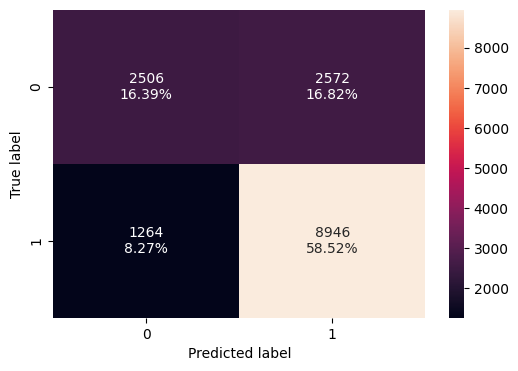

In [42]:
confusion_matrix_sklearn(abc_tuned, X_train, y_train)

In [43]:
abc_tuned_model_train_perf = model_performance_classification_sklearn(abc_tuned, X_train, y_train)

,Accuracy,Recall,Precision,F1
0,0.749084,0.8762,0.776697,0.823454


### Checking model performance on validation set

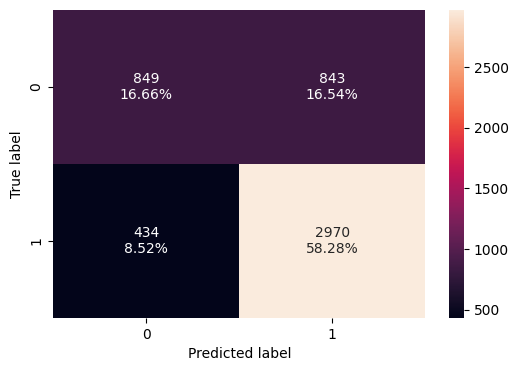

In [44]:
confusion_matrix_sklearn(abc_tuned, X_val, y_val)

In [45]:
abc_tuned_model_val_perf = model_performance_classification_sklearn(abc_tuned, X_val, y_val)
abc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.749411,0.872503,0.778914,0.823057


### Observation:

The tuned AdaBoost model shows consistent performance, with training F1 of 0.8235 and validation F1 of 0.8231. The train-validation F1 gap is minimal at 0.0004, indicating excellent generalization and virtually no overfitting. While some Denied cases are still misclassified as Certified (approx. 843 False Positives on validation) and Certified cases are misclassified as Denied (approx. 434 False Negatives on validation), the model maintains a balanced performance with validation precision of 0.7789 and recall of 0.8725.

## Hyperparameter Tuning - Gradient Boosting Classifier

In [46]:
%%time
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "subsample": [0.7,0.9],
    "max_features": [0.7, 0.8, 0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned,
    parameters,
    scoring=acc_scorer,
    cv=5,
    n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

CPU times: user 7.55 s, sys: 598 ms, total: 8.15 s
Wall time: 10min 31s


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7,
                           n_estimators=np.int64(50), random_state=1,
                           subsample=0.7)

### Checking model performance on training set

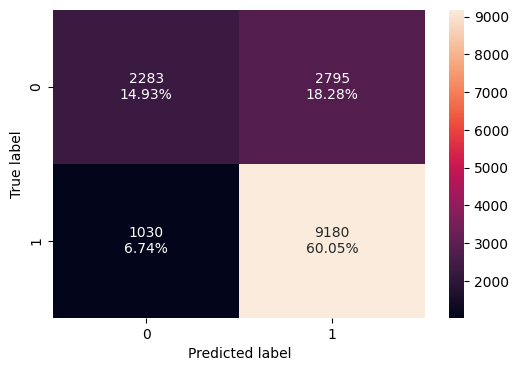

In [47]:
confusion_matrix_sklearn(gbc_tuned, X_train, y_train)

In [48]:
gbc_tuned_model_train_perf = model_performance_classification_sklearn(gbc_tuned, X_train, y_train)
gbc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.749804,0.899119,0.766597,0.827586


### Checking model performance on validation set

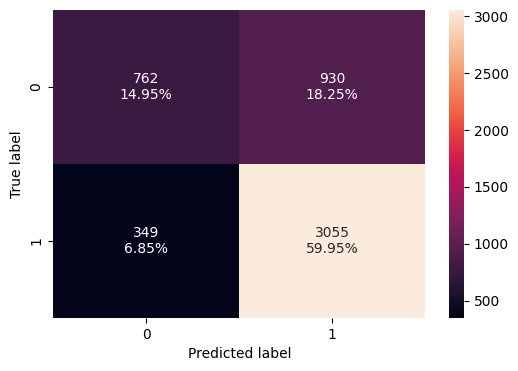

In [49]:
confusion_matrix_sklearn(gbc_tuned, X_val, y_val)

In [50]:
gbc_tuned_model_val_perf = model_performance_classification_sklearn(gbc_tuned, X_val, y_val)
gbc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.749019,0.897474,0.766625,0.826905


### Observations:

The tuned Gradient Boosting model achieves a training F1 of 0.8276 and validation F1 of 0.8269, with a very small train-validation gap of 0.0007, indicating strong and consistent performance with minimal overfitting. On the validation set, approximately 930 Denied cases are misclassified as Certified (False Positives) and 348 Certified cases are misclassified as Denied (False Negatives). This model demonstrates stable generalization, comparable to the tuned AdaBoost model.

In [51]:
%%time
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "scale_pos_weight": [1,2,5],
    "subsample": [0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
    "gamma": [1,3]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned,
    parameters,
    scoring=acc_scorer,
    cv=5,
    n_jobs=-1)  ## Complete the code to define the grid search object
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

CPU times: user 3.48 s, sys: 335 ms, total: 3.81 s
Wall time: 2min 19s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(50), n_jobs=None,
              num_parallel_tree=None, ...)

### Checking model performance on training set

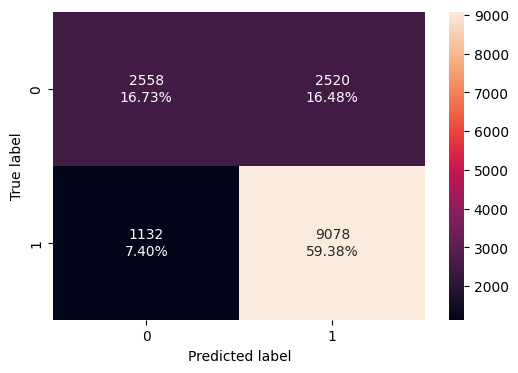

In [52]:
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

In [53]:
xgb_tuned_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.76112,0.889128,0.782721,0.832539


### Checking model performance on validation set

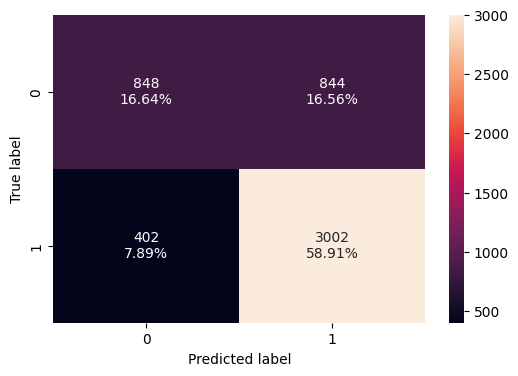

In [54]:
confusion_matrix_sklearn(xgb_tuned, X_val, y_val)

In [55]:
xgb_tuned_model_val_perf = model_performance_classification_sklearn(xgb_tuned, X_val, y_val)
xgb_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.755495,0.881904,0.780551,0.828138


###Observation:
The tuned XGBoost model shows strong generalization with a small train-validation F1 gap (0.0044), performing consistently across both training (F1: 0.8325) and validation (F1: 0.8281) sets. On the validation set, approximately 844 Denied cases are misclassified as Certified (False Positives) and 401 Certified cases are misclassified as Denied (False Negatives). The model still misclassifies around 16.6% of total cases as False Positives, similar to other tuned models in this aspect. Overall, XGBoost is a stable model, comparable in performance to the tuned AdaBoost and GBM.

###Note
The Decision Tree model was not chosen for tuning because it showed the worst overfitting among all the initial models. Its large training-validation recall gap (0.2521) indicated it was essentially memorizing the training data, making it a poor candidate for generalization to unseen data compared to the other ensemble models.

# **Model Comparison and Final Model Selection**

In [56]:
#training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_tuned_model_train_perf.T,
        abc_tuned_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier Tuned",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Tuned Random Forest,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier Tuned
Accuracy,0.806580,0.749084,0.749804,0.761120
Recall,0.916552,0.876200,0.899119,0.889128
Precision,0.816366,0.776697,0.766597,0.782721
F1,0.863563,0.823454,0.827586,0.832539


In [57]:
#validation performance comparison

models_train_comp_df = pd.concat(
    [
        rf_tuned_model_val_perf.T,
        abc_tuned_model_val_perf.T,
        gbc_tuned_model_val_perf.T,
        xgb_tuned_model_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier Tuned",
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Tuned Random Forest,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier Tuned
Accuracy,0.744702,0.749411,0.749019,0.755495
Recall,0.868096,0.872503,0.897474,0.881904
Precision,0.776202,0.778914,0.766625,0.780551
F1,0.819581,0.823057,0.826905,0.828138


###Observation:
Based on the validation performance, the Tuned XGBoost Classifier achieved the highest F1 score. This suggests it is the most robust and well-generalized model among the ones tuned.Using the Tuned XGBoost Classifier for calculating the final test performance.

In [58]:
# Let's check the performance on test set
xgb_test = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
xgb_test

,Accuracy,Recall,Precision,F1
0,0.74117,0.878378,0.767651,0.81929


### Feature Importance

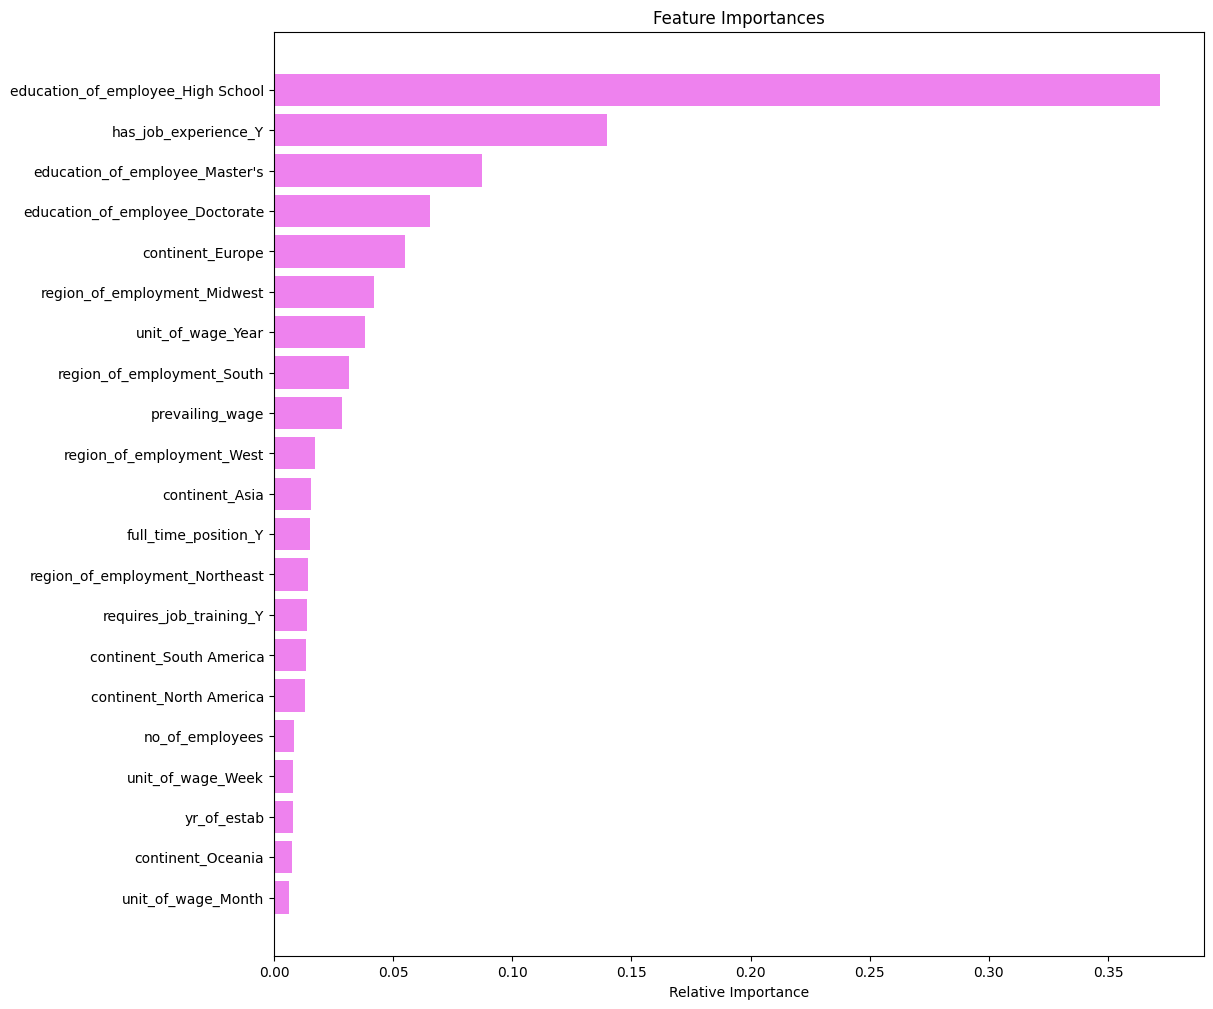

In [59]:
feature_names = X_train.columns
importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### Observations from Feature Importance

Based on the XGBoost model's feature importances, the following are the most influential factors in predicting visa case status:

*   **`education_of_employee_High School`**: This is by far the most important feature, indicating a strong negative correlation with visa approval for applicants with only a high school education, as seen in earlier EDA.
*   **`has_job_experience_Y`**: The presence of job experience is a significant positive predictor for visa approval.
*   **`education_of_employee_Master's`**: Having a Master's degree is another key positive indicator for visa certification.
*   **`education_of_employee_Doctorate`**: Similar to a Master's, a Doctorate degree is also a highly influential factor for approval.

These insights underscore the importance of an applicant's educational background and prior work experience in the visa approval process. The model heavily relies on these features to make its predictions.

# **Actionable Insights and Recommendations**

##Insights


*   After tuning and evaluating all models, XGBoost emerged as the best performing model with the most consistent results across training, validation, and test sets — making it our final choice for predicting visa approval outcomes.
*  Education level plays a significant role in visa decisions. Applicants with a Master's or Doctorate degree show a notably stronger likelihood of getting their visa certified, suggesting employers filing for highly educated candidates tend to meet approval criteria more easily.
*  Work experience also matters — applicants with prior job experience have a meaningfully better chance of visa approval, which aligns with the expectation that employers prefer and sponsor candidates who bring proven skills to the role.





## Recommendations

1. Employers should genuinely prioritize candidates with Master's or Doctorate degrees and hands-on job experience — the data makes it clear these are the profiles that get approved. Building a hiring pipeline around these criteria from the start just makes the whole process smoother and less wasteful.
2.  Full-time permanent roles consistently showed better approval outcomes. If an employer has flexibility in how a role is structured, filing for a full-time position rather than a contractual or part-time arrangement is simply the smarter move.
3. For candidates who are still building their profile, investing in structured skill-based training programs before filing could make a real difference. Interestingly, not requiring job training came up as a positive signal in the data-which means candidates who already arrive job-ready have a better chance.
